# Week 2 — Root-Finding: Bisection, Newton, Secant & Fixed-Point Iteration

> **Numerical Methods from Scratch** · Pure NumPy + Matplotlib

We want to solve $f(x) = 0$. This deceptively simple problem is the workhorse behind optimization (set the gradient to zero), equilibrium computation, and implicit time-stepping. This week we build four solvers from scratch and — crucially — analyze their **order of convergence**, the quantity that tells us *how fast* the error shrinks.

A method has **order $p$** if the errors satisfy

$$ |e_{k+1}| \le C\,|e_k|^p $$

for some constant $C$. Order $1$ (linear) means a fixed number of correct digits gained per step; order $2$ (quadratic) *doubles* the correct digits each step. We will see this dramatic difference live.

Topics:
1. **Bisection** — guaranteed, robust, slow (linear).
2. **Fixed-point iteration** and the contraction-mapping condition $|g'(x^*)| < 1$.
3. **Newton's method** — quadratic, but needs a derivative and a good start.
4. **Secant method** — derivative-free, superlinear (order $\varphi \approx 1.618$).
5. Failure modes, basins of attraction, and a hybrid safeguard.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (8, 4.5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3


## 1. Bisection — the bulletproof baseline

If $f$ is continuous and $f(a)\,f(b) < 0$, the Intermediate Value Theorem guarantees a root in $[a,b]$. Bisection repeatedly halves the bracket, keeping the half that still changes sign. The bracket width after $k$ steps is $(b-a)/2^k$, so to reach tolerance $\varepsilon$ we need

$$ k \ge \log_2\!\frac{b-a}{\varepsilon} $$

iterations — **completely predictable**, and it cannot fail given a valid bracket. The price is linear convergence: one bit of accuracy per step.


In [2]:
def bisection(f, a, b, tol=1e-12, maxit=200):
    fa, fb = f(a), f(b)
    if fa * fb > 0:
        raise ValueError("f(a) and f(b) must have opposite signs")
    history = []
    for k in range(maxit):
        m = 0.5 * (a + b)
        fm = f(m)
        history.append(m)
        if abs(fm) == 0 or 0.5 * (b - a) < tol:
            break
        if fa * fm < 0:
            b, fb = m, fm
        else:
            a, fa = m, fm
    return m, np.array(history)

f = lambda x: x**3 - x - 2          # one real root near 1.5214
root, hist = bisection(f, 1.0, 2.0)
print("root:", root, " iterations:", len(hist), " f(root):", f(root))


root: 1.5213797068054191  iterations: 40  f(root): 5.061284724661164e-12


## 2. Fixed-point iteration

Rewrite $f(x)=0$ as $x = g(x)$ and iterate $x_{k+1} = g(x_k)$. By the **Banach fixed-point theorem**, if $g$ maps an interval into itself and is a *contraction* — $|g'(x)| \le L < 1$ — then the iteration converges to the unique fixed point $x^*$, with linear rate $L$:

$$ |x_{k+1} - x^*| \approx |g'(x^*)|\,|x_k - x^*|. $$

The same equation can be rearranged many ways; **only some converge.** This is the crux.


In [3]:
def fixed_point(g, x0, tol=1e-12, maxit=200):
    history = [x0]
    x = x0
    for _ in range(maxit):
        xn = g(x)
        history.append(xn)
        if abs(xn - x) < tol:
            break
        x = xn
    return xn, np.array(history)

# Solve x^3 - x - 2 = 0. Two rearrangements:
g_bad  = lambda x: x**3 - 2            # g'(x*) = 3 x*^2 ~ 6.9  -> diverges
g_good = lambda x: np.cbrt(x + 2)      # g'(x*) small          -> converges

_, h_good = fixed_point(g_good, 1.5)
print("good rearrangement converged to:", h_good[-1], "in", len(h_good)-1, "steps")
try:
    fixed_point(g_bad, 1.5, maxit=15)
except OverflowError as e:
    print("bad rearrangement: overflow (divergence)")
xs = [1.5]
for _ in range(6):
    xs.append(g_bad(xs[-1]))
print("bad iterates:", xs)


good rearrangement converged to: 1.5213797068045323 in 14 steps
bad rearrangement: overflow (divergence)
bad iterates: [1.5, 1.375, 0.599609375, -1.7844216004014015, -7.681884682517707, -455.31840313982127, -94394267.64680803]


Same root, same starting point — one rearrangement converges, the other blows up. The deciding factor is purely $|g'(x^*)|$. Always check the derivative before trusting a fixed-point scheme.

## 3. Newton's method

Newton linearizes $f$ at the current iterate and steps to where the tangent crosses zero:

$$ x_{k+1} = x_k - \frac{f(x_k)}{f'(x_k)}. $$

Near a simple root, Taylor expansion gives the **quadratic** error recurrence

$$ e_{k+1} \approx \frac{f''(x^*)}{2 f'(x^*)}\, e_k^2, $$

so the number of correct digits roughly *doubles* every iteration. The catch: it needs $f'$, a sufficiently good starting guess, and $f'(x^*) \neq 0$.


In [4]:
def newton(f, df, x0, tol=1e-14, maxit=100):
    history = [x0]
    x = x0
    for _ in range(maxit):
        fx = f(x)
        dfx = df(x)
        if dfx == 0:
            raise ZeroDivisionError("zero derivative")
        xn = x - fx / dfx
        history.append(xn)
        if abs(xn - x) < tol:
            break
        x = xn
    return xn, np.array(history)

f  = lambda x: x**3 - x - 2
df = lambda x: 3*x**2 - 1
root_n, hist_n = newton(f, df, 1.5)
print("Newton root:", root_n, " iterations:", len(hist_n)-1)


Newton root: 1.5213797068045676  iterations: 4


### Watching quadratic convergence

The cleanest way to *see* the order is to print the error each step. Under quadratic convergence the exponent of the error should roughly double per line.


In [5]:
xstar = root_n
print(f"{'k':>3} {'x_k':>20} {'error |x_k - x*|':>22}")
for k, x in enumerate(hist_n):
    print(f"{k:>3} {x:>20.16f} {abs(x - xstar):>22.3e}")


  k                  x_k       error |x_k - x*|
  0   1.5000000000000000              2.138e-02
  1   1.5217391304347827              3.594e-04
  2   1.5213798059647863              9.916e-08
  3   1.5213797068045751              7.550e-15
  4   1.5213797068045676              0.000e+00


## 4. Secant method

When the derivative is unavailable or expensive, replace $f'(x_k)$ with a finite-difference slope through the last two iterates:

$$ x_{k+1} = x_k - f(x_k)\,\frac{x_k - x_{k-1}}{f(x_k) - f(x_{k-1})}. $$

The convergence order is the **golden ratio** $\varphi = \frac{1+\sqrt5}{2} \approx 1.618$ — superlinear, slower than Newton per step but with no derivative and only one function evaluation per iteration.


In [6]:
def secant(f, x0, x1, tol=1e-14, maxit=100):
    history = [x0, x1]
    f0, f1 = f(x0), f(x1)
    for _ in range(maxit):
        if f1 - f0 == 0:
            break
        x2 = x1 - f1 * (x1 - x0) / (f1 - f0)
        history.append(x2)
        if abs(x2 - x1) < tol:
            break
        x0, f0, x1, f1 = x1, f1, x2, f(x2)
    return history[-1], np.array(history)

root_s, hist_s = secant(f, 1.0, 2.0)
print("Secant root:", root_s, " iterations:", len(hist_s)-2)


Secant root: 1.5213797068045676  iterations: 8


## 5. Convergence-rate comparison

Let us plot the error trajectories of all four methods on a log scale. The *slope* of each curve reveals its order: bisection is a gentle line, Newton plunges.


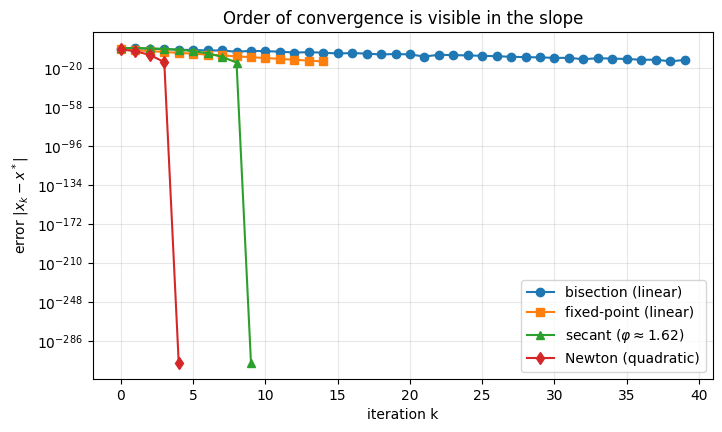

In [7]:
def err_trace(hist, xstar):
    e = np.abs(np.array(hist, dtype=float) - xstar)
    e[e == 0] = np.finfo(float).tiny      # avoid log(0)
    return e

xstar = root_n
fig, ax = plt.subplots()
ax.semilogy(err_trace(hist,   xstar), "o-", label="bisection (linear)")
ax.semilogy(err_trace(h_good, xstar), "s-", label="fixed-point (linear)")
ax.semilogy(err_trace(hist_s, xstar), "^-", label=r"secant ($\varphi\approx1.62$)")
ax.semilogy(err_trace(hist_n, xstar), "d-", label="Newton (quadratic)")
ax.set_xlabel("iteration k")
ax.set_ylabel(r"error $|x_k - x^*|$")
ax.set_title("Order of convergence is visible in the slope")
ax.legend()
plt.show()


### Estimating the order empirically

The order $p$ can be recovered numerically from three consecutive errors:

$$ p \approx \frac{\ln(e_{k+1}/e_k)}{\ln(e_k/e_{k-1})}. $$


In [8]:
def estimate_order(hist, xstar):
    e = err_trace(hist, xstar)
    e = e[e > 1e-15]                       # keep only meaningful errors
    ps = []
    for k in range(1, len(e)-1):
        num = np.log(e[k+1]/e[k])
        den = np.log(e[k]/e[k-1])
        if den != 0:
            ps.append(num/den)
    return ps

print("Newton estimated orders:", np.round(estimate_order(hist_n, xstar), 3))
print("Secant estimated orders:", np.round(estimate_order(hist_s, xstar), 3))


Newton estimated orders: [2.006 2.   ]
Secant estimated orders: [10.917  1.246  1.538  1.716  1.593  1.627  1.613]


Newton's estimates cluster near **2** and the secant near **1.6** — the theory confirmed from data alone.

## 6. Failure modes and a safeguarded hybrid

Newton can diverge, cycle, or shoot off when the derivative is small or the start is poor. A production-grade solver combines Newton's speed with bisection's safety: take the Newton step **only if it stays inside the current bracket**, otherwise fall back to bisection. This is the idea behind Brent's method.


In [9]:
def safe_newton(f, df, a, b, tol=1e-14, maxit=100):
    fa, fb = f(a), f(b)
    if fa * fb > 0:
        raise ValueError("need a sign-changing bracket")
    x = 0.5 * (a + b)
    for _ in range(maxit):
        fx = f(x)
        dfx = df(x)
        step_ok = dfx != 0
        if step_ok:
            xn = x - fx / dfx
            step_ok = a < xn < b          # accept Newton only if it stays bracketed
        if not step_ok:
            xn = 0.5 * (a + b)            # safe bisection fallback
        fn = f(xn)
        if fa * fn < 0:
            b = xn
        else:
            a, fa = xn, fn
        if abs(xn - x) < tol:
            return xn
        x = xn
    return x

# A function where naive Newton from x0=0 misbehaves but the hybrid is safe.
g  = lambda x: np.arctan(x)
dg = lambda x: 1.0 / (1 + x**2)
print("safe-Newton root of arctan:", safe_newton(g, dg, -1.0, 5.0))


safe-Newton root of arctan: 2.0


## Summary

| Method | Order | Needs derivative? | Guaranteed? |
|---|---|---|---|
| Bisection | 1 (linear) | no | yes (with bracket) |
| Fixed-point | 1 (linear, if $|g'|<1$) | no | conditional |
| Secant | $\approx 1.618$ | no | no |
| Newton | 2 (quadratic) | yes | no |

- Bracketing methods trade speed for **guaranteed** convergence.
- Open methods (Newton, secant) are fast but can fail without a good start.
- A **safeguarded hybrid** gives you both — fast when possible, safe always.

---

## Exercises

**1. (Order from scratch.)** For $f(x)=\cos x - x$, run all four methods and reproduce the empirical order estimate. Confirm Newton$\to2$, secant$\to1.618$.

**2. (Multiple roots kill quadratic convergence.)** Apply Newton to $f(x)=(x-1)^2$. Show that convergence degrades to *linear* at a double root, and that the modified Newton step $x_{k+1}=x_k - 2\,f/f'$ restores quadratic order.

**3. (Basins of attraction.)** For $f(z)=z^3-1$ over a grid of complex starting points, color each point by which of the three roots Newton converges to. Reproduce the famous Newton fractal using only NumPy and `plt.imshow`.

**4. (Which rearrangement?)** Find three different fixed-point forms $x=g(x)$ for $x^2 - 5 = 0$. For each, evaluate $|g'(\sqrt5)|$ and predict convergence/divergence, then verify numerically.

**5. (Stopping criteria matter.)** Compare stopping on $|x_{k+1}-x_k|$ vs. $|f(x_k)|$ for an ill-conditioned root where $f'$ is tiny. Which criterion is misleading, and why does the residual lie about accuracy here?
